<a href="https://www.kaggle.com/code/lalit7881/ai-jobs-salaries-2025-26?scriptVersionId=301914628" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
import os
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries/ai_jobs_market_2025_2026.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries/ai_jobs_market_2025_2026.csv")

In [3]:
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [4]:
df.tail()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
1495,AIJOB1496,Multimodal AI Engineer,AI Engineering,Lead (10+ yrs),8,Master's,262000.0,160000,300000,Toronto,...,8.8,90,23.6,7.5,2026,1,1,1,0,Senior ($200-300k)
1496,AIJOB1497,NLP Engineer,AI Engineering,Senior (6-9 yrs),9,Bootcamp/Self-taught,163000.0,145000,290000,Berlin,...,6.7,91,66.5,7.8,2025,3,1,0,0,Upper-Mid ($150-200k)
1497,AIJOB1498,AI Compliance Manager,Governance,Mid (3-5 yrs),10,Master's,127000.0,100000,200000,Zurich,...,10.9,68,15.3,8.3,2026,3,0,1,0,Mid ($100-150k)
1498,AIJOB1499,NLP Engineer,AI Engineering,Lead (10+ yrs),4,Bachelor's,145000.0,145000,290000,Bangalore,...,8.5,91,78.8,7.4,2025,5,1,1,0,Mid ($100-150k)
1499,AIJOB1500,AI Security Engineer,Security,Lead (10+ yrs),5,Master's,229000.0,140000,260000,Berlin,...,12.2,80,9.0,8.6,2025,6,1,1,0,Senior ($200-300k)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

In [6]:
df.describe()

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,135448.666667,257537.333333,10.858200,87.523333,31.116333,7.897333,2025.584000,3.968000,0.496667,0.754000,0.218000
std,2.675216,66506.822013,24448.950878,39852.822207,4.029742,8.026315,22.046343,1.102846,0.493058,3.270388,0.500156,0.430822,0.413025
min,1.000000,90000.000000,90000.000000,180000.000000,3.000000,68.000000,5.000000,6.000000,2025.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,144750.000000,120000.000000,218000.000000,8.200000,82.000000,15.375000,6.900000,2025.000000,2.000000,0.000000,1.000000,0.000000
50%,6.000000,180000.000000,140000.000000,270000.000000,10.500000,89.000000,23.400000,7.900000,2026.000000,3.000000,0.000000,1.000000,0.000000
75%,8.000000,236250.000000,155000.000000,290000.000000,14.200000,95.000000,42.700000,8.900000,2026.000000,5.000000,1.000000,1.000000,0.000000
max,15.000000,384000.000000,180000.000000,320000.000000,18.000000,98.000000,87.800000,9.800000,2026.000000,12.000000,1.000000,1.000000,1.000000


In [7]:
df.dtypes

job_id                    object
job_title                 object
job_category              object
experience_level          object
years_of_experience        int64
education_required        object
annual_salary_usd        float64
salary_min_usd             int64
salary_max_usd             int64
city                      object
country                   object
remote_work               object
company_size              object
industry                  object
required_skills           object
ai_salary_premium_pct    float64
demand_score               int64
demand_growth_yoy_pct    float64
benefits_score_10        float64
posting_year               int64
posting_month              int64
is_senior                  int64
is_remote_friendly         int64
is_llm_role                int64
salary_tier               object
dtype: object

In [8]:
df.shape

(1500, 25)

In [9]:
df.isnull().sum()

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier'],
      dtype='object')

In [12]:
df.nunique()

job_id                   1500
job_title                  25
job_category               12
experience_level            4
years_of_experience        15
education_required          5
annual_salary_usd         248
salary_min_usd             17
salary_max_usd             16
city                       20
country                    14
remote_work                 3
company_size                5
industry                   12
required_skills          1500
ai_salary_premium_pct     151
demand_score               20
demand_growth_yoy_pct     565
benefits_score_10          39
posting_year                2
posting_month              12
is_senior                   2
is_remote_friendly          2
is_llm_role                 2
salary_tier                 5
dtype: int64

## EDA

In [13]:
plt.style.use("dark_background")
sns.set_palette("bright")

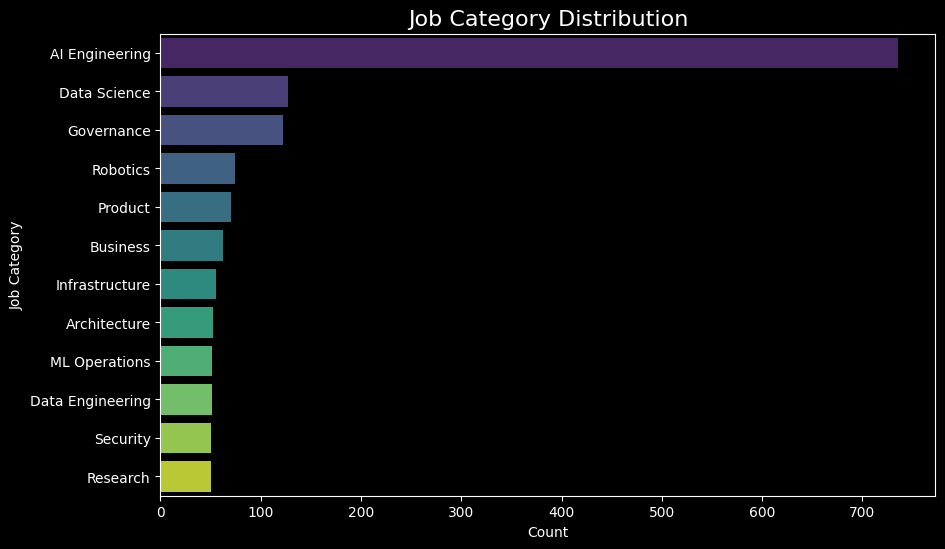

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=df["job_category"],
    order=df["job_category"].value_counts().index,
    palette="viridis"
)

plt.title("Job Category Distribution", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Job Category")

plt.show()

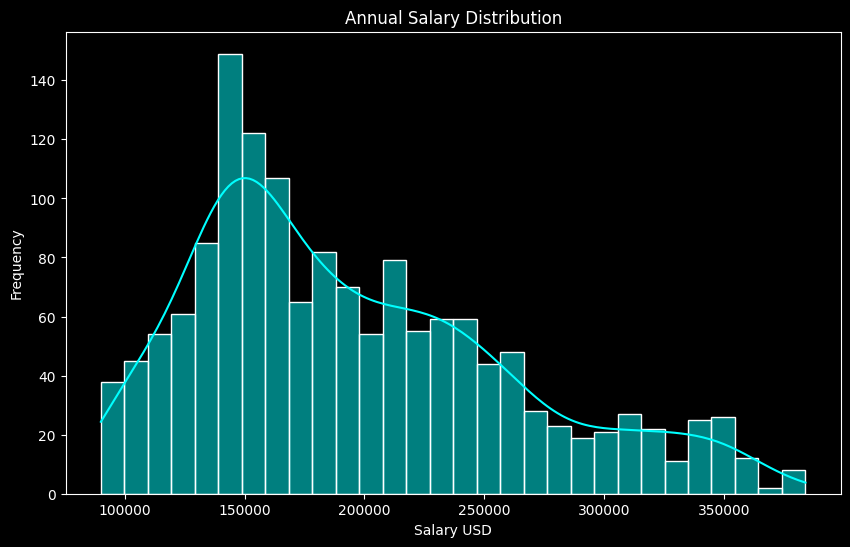

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["annual_salary_usd"],
    bins=30,
    kde=True,
    color="cyan"
)

plt.title("Annual Salary Distribution")
plt.xlabel("Salary USD")
plt.ylabel("Frequency")

plt.show()

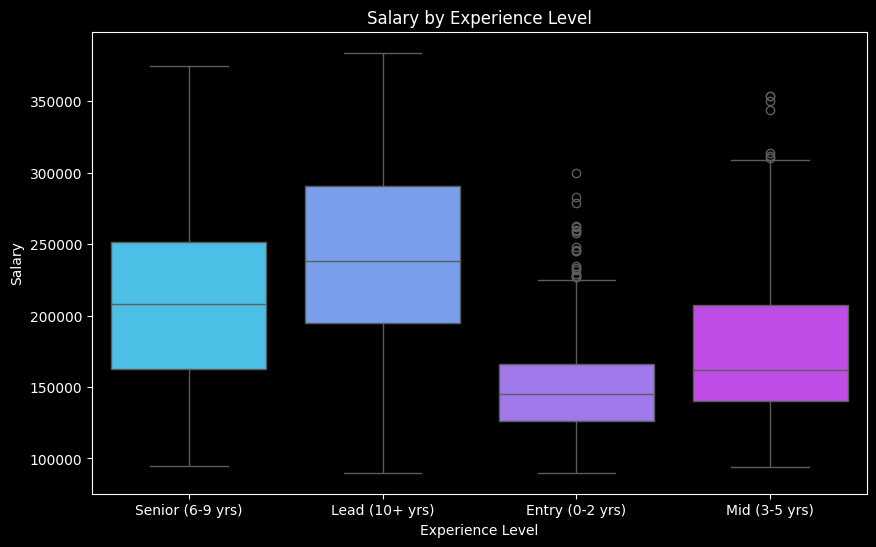

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="experience_level",
    y="annual_salary_usd",
    data=df,
    palette="cool"
)

plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary")

plt.show()

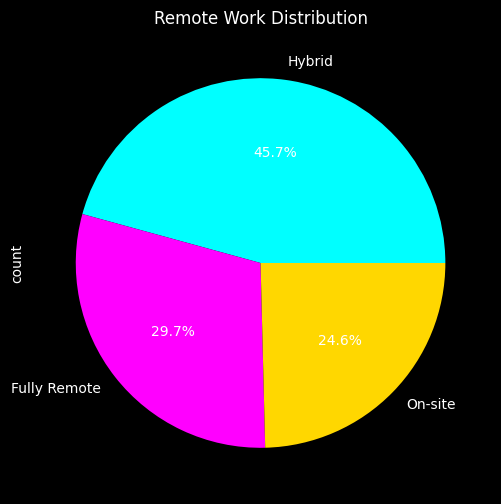

In [17]:
plt.figure(figsize=(8,6))

df["remote_work"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#00FFFF","#FF00FF","#FFD700"]
)

plt.title("Remote Work Distribution")

plt.show()

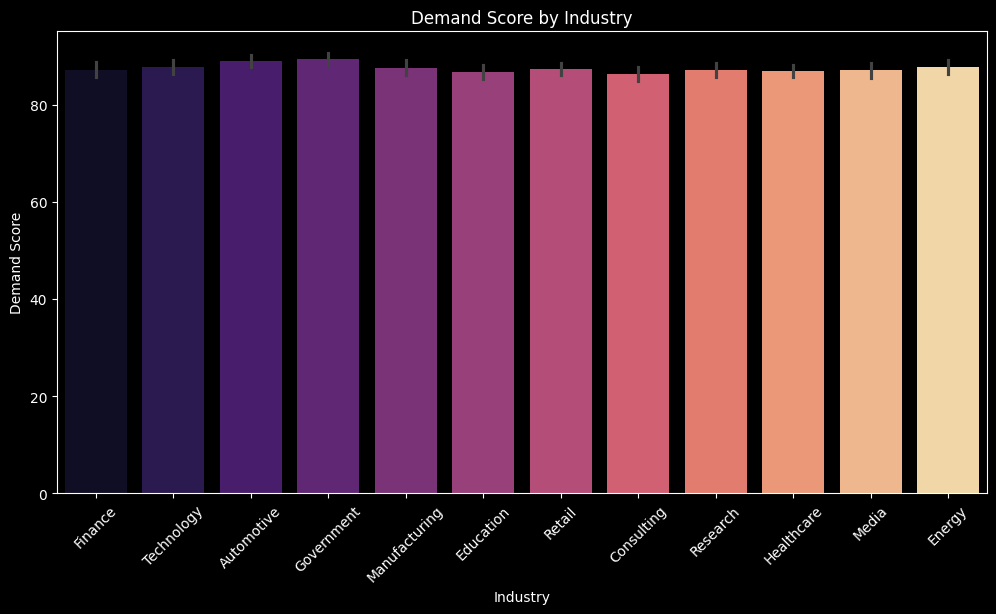

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="industry",
    y="demand_score",
    data=df,
    palette="magma"
)

plt.xticks(rotation=45)

plt.title("Demand Score by Industry")
plt.xlabel("Industry")
plt.ylabel("Demand Score")

plt.show()

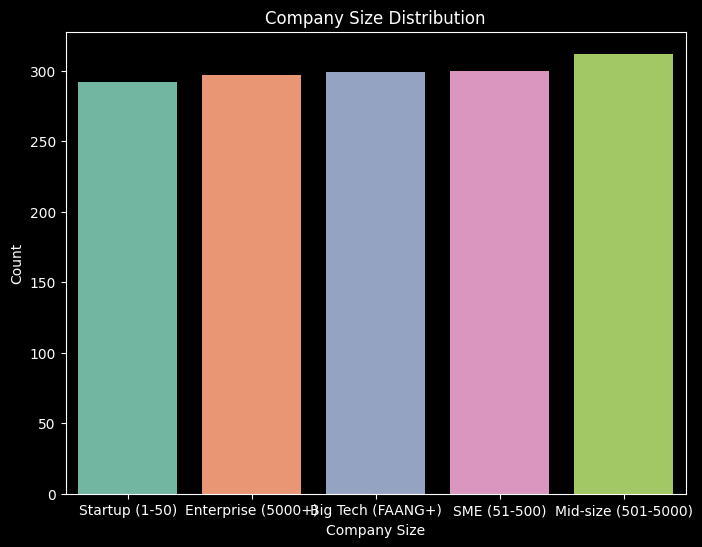

In [19]:
plt.figure(figsize=(8,6))

sns.countplot(
    x="company_size",
    data=df,
    palette="Set2"
)

plt.title("Company Size Distribution")
plt.xlabel("Company Size")
plt.ylabel("Count")

plt.show()

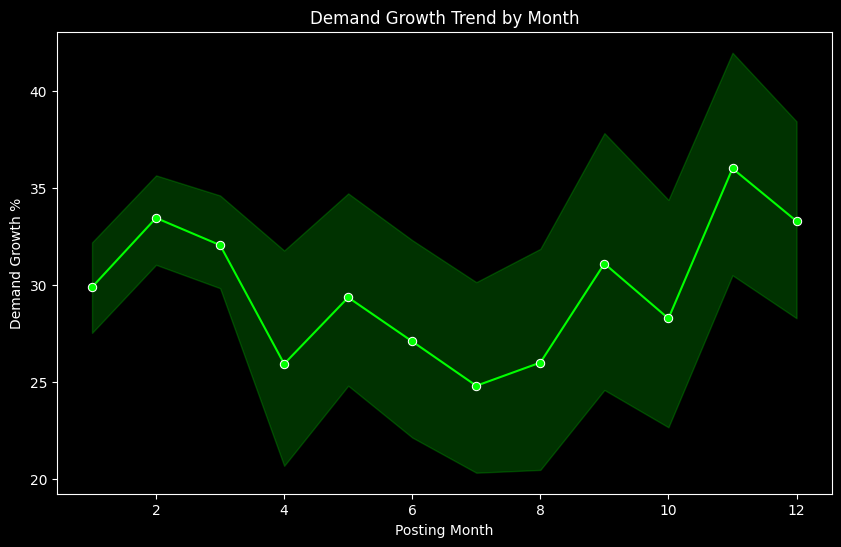

In [20]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x="posting_month",
    y="demand_growth_yoy_pct",
    data=df,
    color="lime",
    marker="o"
)

plt.title("Demand Growth Trend by Month")
plt.xlabel("Posting Month")
plt.ylabel("Demand Growth %")

plt.show()

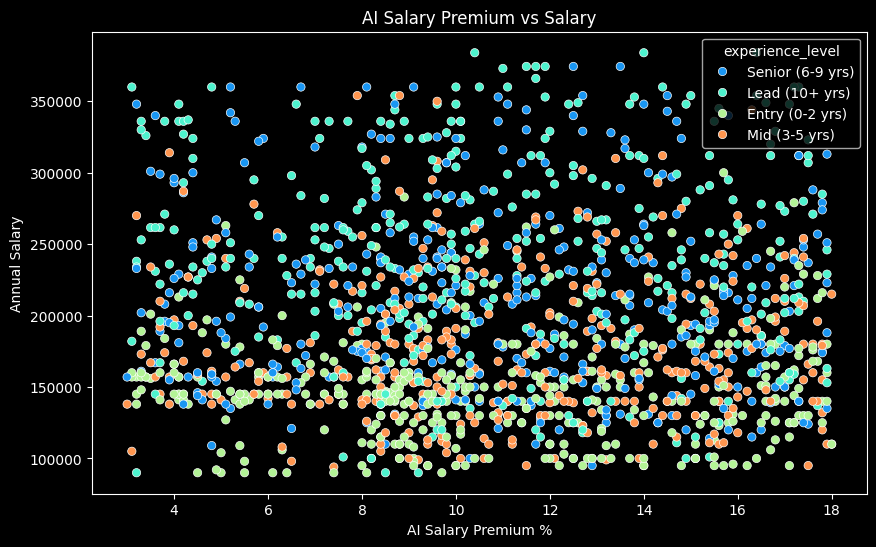

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="ai_salary_premium_pct",
    y="annual_salary_usd",
    hue="experience_level",
    palette="rainbow",
    data=df
)

plt.title("AI Salary Premium vs Salary")
plt.xlabel("AI Salary Premium %")
plt.ylabel("Annual Salary")

plt.show()


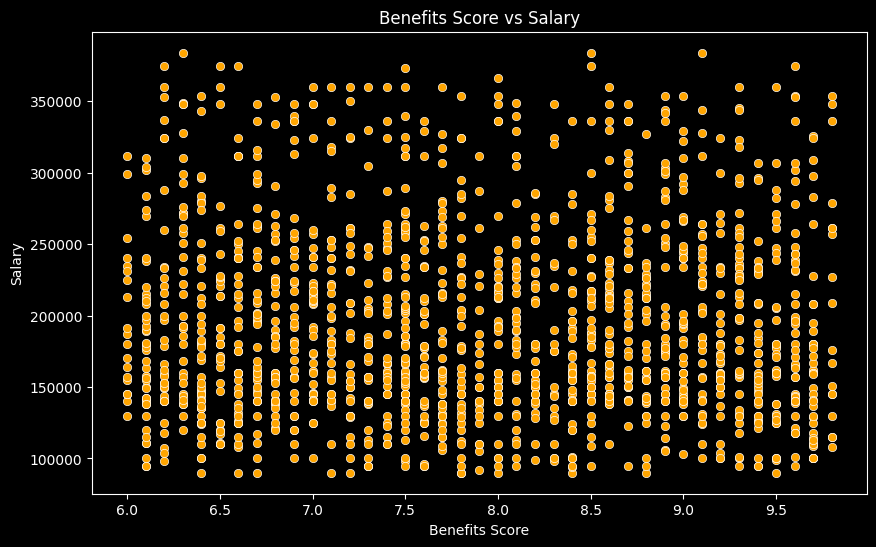

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="benefits_score_10",
    y="annual_salary_usd",
    color="orange",
    data=df
)

plt.title("Benefits Score vs Salary")
plt.xlabel("Benefits Score")
plt.ylabel("Salary")

plt.show()

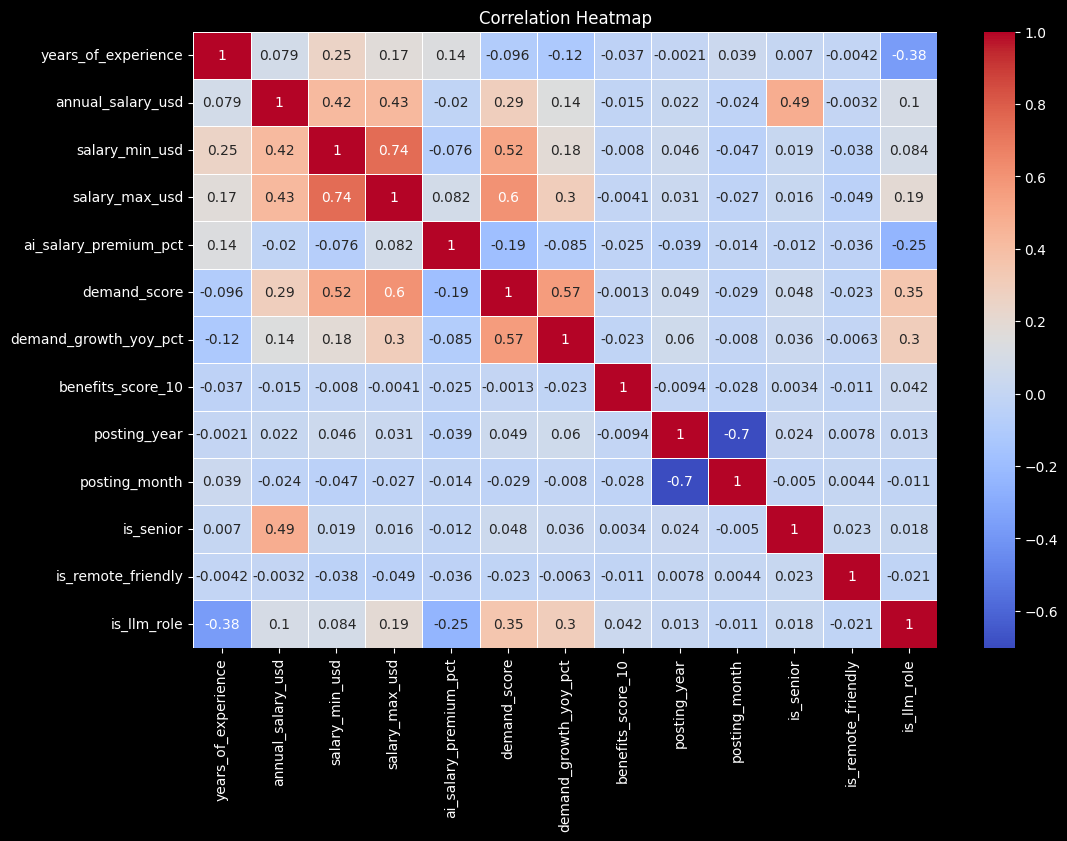

In [23]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## feature engineering

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [25]:
df = df.drop(["job_id","job_title","required_skills"], axis=1)

In [26]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [27]:
X = df.drop("salary_tier", axis=1)
y = df["salary_tier"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [30]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=2000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()

}

results = {}

In [31]:
classes = sorted(y.unique())
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)



MODEL: Logistic Regression
Accuracy: 92.33 %


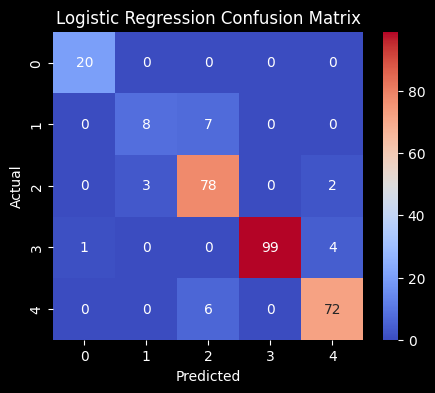


MODEL: Decision Tree
Accuracy: 100.0 %


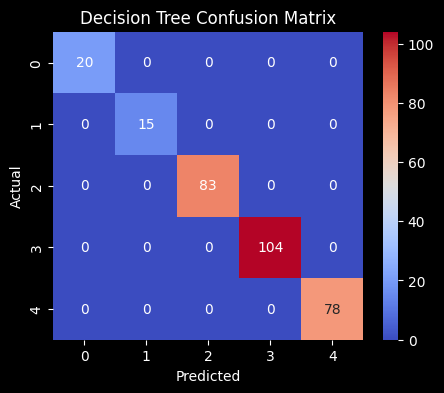


MODEL: Random Forest
Accuracy: 99.0 %


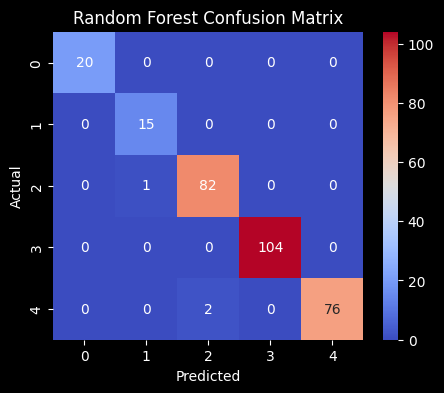


MODEL: KNN
Accuracy: 63.33 %


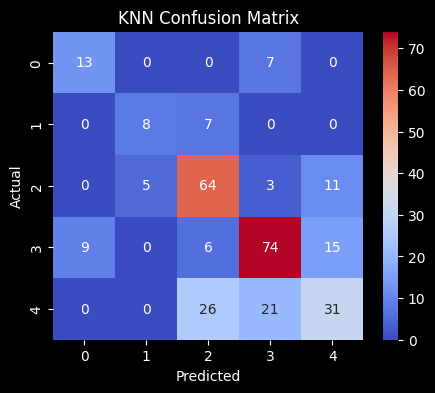


MODEL: Naive Bayes
Accuracy: 92.67 %


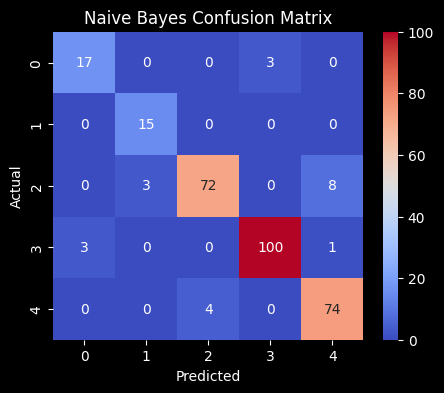

In [32]:
for name, model in models.items():

    print("\n"+"="*60)
    print("MODEL:", name)
    print("="*60)

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc * 100

    print("Accuracy:", round(acc*100,2), "%")

    # =====================================
    # CONFUSION MATRIX
    # =====================================
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="coolwarm")

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

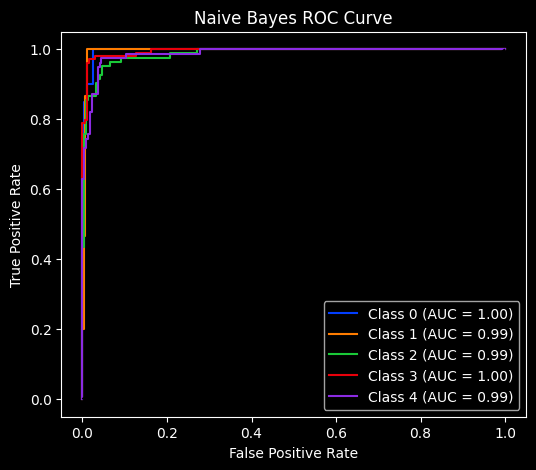

In [33]:
if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test)

        plt.figure(figsize=(6,5))

        for i in range(n_classes):

            fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])

            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr,
                     label="Class %d (AUC = %.2f)" % (i, roc_auc))

        plt.plot([0,1],[0,1],'k--')

        plt.title(name + " ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.legend()

        plt.show()

In [34]:
print("\nFinal Accuracy Comparison")
print("="*40)

for model, acc in results.items():
    print(model, ":", round(acc,2), "%")



Final Accuracy Comparison
Logistic Regression : 92.33 %
Decision Tree : 100.0 %
Random Forest : 99.0 %
KNN : 63.33 %
Naive Bayes : 92.67 %


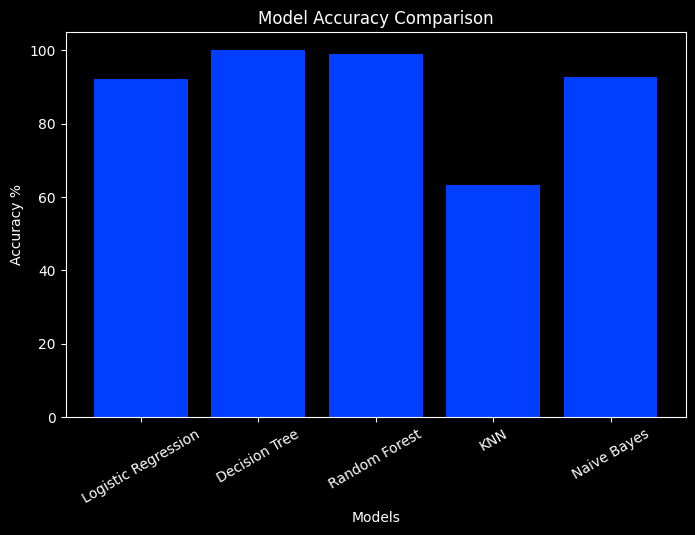

In [35]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy %")

plt.xticks(rotation=30)

plt.show()